# LAB 5

- Alunos:
    - Orlando Virginio Penha Junior

## Imports

In [ ]:
import pandas as pd
from datasets import load_dataset

/home/orlandojunior/miniconda3/envs/kaggle/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Leitura dos Dados

In [2]:
# df_attorneys = load_dataset("jamiequint/sf_criminal_court", "attorneys")["train"].to_pandas()
# df_calendar = load_dataset("jamiequint/sf_criminal_court", "calendar")["train"].to_pandas()
# df_calendar_jud = load_dataset("jamiequint/sf_criminal_court", "calendar_with_judicial_assignments")["train"].to_pandas()
# df_cases = load_dataset("jamiequint/sf_criminal_court", "cases")["train"].to_pandas()
df_da_arrests = load_dataset("jamiequint/sf_criminal_court", "da_arrests")["train"].to_pandas()
df_da_prosecuted = load_dataset("jamiequint/sf_criminal_court", "da_prosecuted")["train"].to_pandas()
# df_jud_assig_src = load_dataset("jamiequint/sf_criminal_court", "judicial_assignment_sources")["train"].to_pandas()
# df_jud_assig = load_dataset("jamiequint/sf_criminal_court", "judicial_assignments")["train"].to_pandas()
# df_jud_dept_assig = load_dataset("jamiequint/sf_criminal_court", "judicial_department_assignments")["train"].to_pandas()
# df_jud_officers = load_dataset("jamiequint/sf_criminal_court", "judicial_officers")["train"].to_pandas()
# df_register = load_dataset("jamiequint/sf_criminal_court", "register_of_actions")["train"].to_pandas()
# df_case_matches = load_dataset("jamiequint/sf_criminal_court", "sfsc_case_matches")["train"].to_pandas()
# df_charge_disp = load_dataset("jamiequint/sf_criminal_court", "sfsc_charge_dispositions")["train"].to_pandas()

## Perguntas para direcionar a análise do Dataset
- 1- Qual é a taxa de casos em que a prisão ocorre por um crime grave (Felony), mas a promotoria decide formalizar a acusação apenas por um delito menor (Misdemeanor)?
- 2- Qual a duração média dos processos ? E processos com mais advogados tendem a ter mais movimentações ?
- 3- Os casos que nunca foram encerrados ou duraram mais de 1 ano são do mesmo juiz? Os crimes desses casos são semelhantes ou os advogados associados são os mesmos?
- 4- Quais os tipos de defensores mais atuantes na corte, publicos ou privados? Qual tipo consegue ser mais eficiente? (Resultado diferente de culpado)

## Pergunta 1

- 1- Qual é a taxa de casos em que a prisão ocorre por um crime grave (Felony), mas a promotoria decide formalizar a acusação apenas por um delito menor (Misdemeanor)?

A resposta dessa pergunta está relacionada com as tabelas de **df_da_arests** e **df_da_prosecuted**

### Análise Exploratória de Dados

In [3]:
df_da_arrests.info()

<class 'pandas.DataFrame'>
RangeIndex: 176130 entries, 0 to 176129
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   incident_number         176130 non-null  str  
 1   court_number            176130 non-null  str  
 2   arrest_date             176130 non-null  str  
 3   arresting_agency        176130 non-null  str  
 4   crime_type              176130 non-null  str  
 5   list_of_booked_charges  176130 non-null  str  
 6   booked_case_type        176130 non-null  str  
 7   dv_case                 176130 non-null  str  
 8   da_action_taken         176130 non-null  str  
 9   data_as_of              176130 non-null  str  
 10  data_loaded_at          176130 non-null  str  
dtypes: str(11)
memory usage: 38.3 MB


In [4]:
df_da_prosecuted.info()

<class 'pandas.DataFrame'>
RangeIndex: 120827 entries, 0 to 120826
Data columns (total 11 columns):
 #   Column                 Non-Null Count   Dtype
---  ------                 --------------   -----
 0   incident_number        120827 non-null  str  
 1   court_number           120827 non-null  str  
 2   arrest_date            120827 non-null  str  
 3   list_of_filed_charges  120827 non-null  str  
 4   filed_case_type        120827 non-null  str  
 5   crime_type             120827 non-null  str  
 6   dv_case                120827 non-null  str  
 7   da_action_taken        120827 non-null  str  
 8   case_status            120827 non-null  str  
 9   data_as_of             120827 non-null  str  
 10  data_loaded_at         120827 non-null  str  
dtypes: str(11)
memory usage: 30.1 MB


In [5]:
df_da_arrests.head()

,incident_number,court_number,arrest_date,arresting_agency,crime_type,list_of_booked_charges,booked_case_type,dv_case,da_action_taken,data_as_of,data_loaded_at
0,140193864,14006811,2014-03-06T00:00:00.000,BART,Narcotics,"11350A,640C1",Felony,No,Further Investigation Requested,2026-04-27T00:00:00.000,2026-04-28T22:05:53.280
1,140183956,14006463,2014-03-03T00:00:00.000,SFPD,Narcotics,"11351,11364.1A,21955",Felony,No,Discharged,2026-04-27T00:00:00.000,2026-04-28T22:05:53.280
2,140272242,14009242,2014-04-01T00:00:00.000,SFPD,Narcotics,11352A,Felony,No,MTR/Referred to Other Agency,2026-04-27T00:00:00.000,2026-04-28T22:05:53.280
3,140299876,14010079,2014-04-10T00:00:00.000,SFPD,Narcotics,"182A1,11352A,11351",Felony,No,MTR/Referred to Other Agency,2026-04-27T00:00:00.000,2026-04-28T22:05:53.280
4,Z20140423-14011228,14011228,2014-04-23T00:00:00.000,SFSU,Narcotics,"148A1,11357A,11350A",Felony,No,Discharged,2026-04-27T00:00:00.000,2026-04-28T22:05:53.280


In [6]:
df_da_prosecuted.head()

,incident_number,court_number,arrest_date,list_of_filed_charges,filed_case_type,crime_type,dv_case,da_action_taken,case_status,data_as_of,data_loaded_at
0,Z20160508-16008776,16008776,2016-05-08T00:00:00.000,"23152A/M/0, 23152B/M/0",Misdemeanor,DUI,No,New charges filed,Dismissal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
1,160390313,2495093,2016-05-13T00:00:00.000,"20002A/M/0, 23152A/M/0, 23152B/M/0",Misdemeanor,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
2,Z20160517-16009375,16009375,2016-05-17T00:00:00.000,"23152A/M/0, 23152B/M/0",Misdemeanor,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
3,Z20160516-16009292,16009292,2016-05-16T00:00:00.000,"23152A/M/0, 23152B/M/0",Misdemeanor,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
4,160357266,16008334,2016-05-01T00:00:00.000,"23152B/M/0, 23152A/M/0",Misdemeanor,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399


<Axes: ylabel='booked_case_type'>

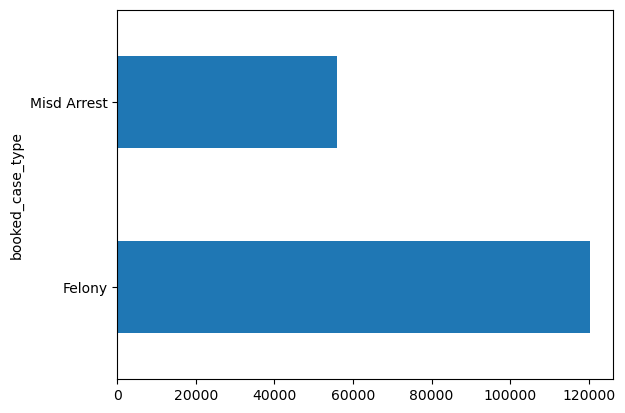

In [7]:
df_da_arrests.value_counts('booked_case_type').plot.barh()

<Axes: ylabel='filed_case_type'>

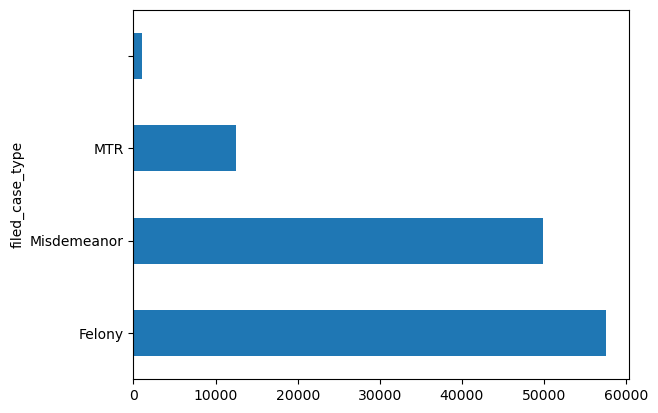

In [8]:
df_da_prosecuted.value_counts('filed_case_type').plot.barh()

Aqui notamos o valor de MTR, que significa Motion to Revoke ("Pedido de Revogação"), também notamos que há valores nulos nesse campo filed_case_type.

In [9]:
df_da_prosecuted['filed_case_type'].unique()

<ArrowStringArray>
['Misdemeanor', 'Felony', '', 'MTR']
Length: 4, dtype: str

In [10]:
df_da_arrests['booked_case_type'].isna().sum()

np.int64(0)

#### Investigando os Dados nulos de df_da_prosecuted

Durante a análise exploratória, identificou-se que o campo filed_case_type do dataframe df_da_prosecuted apresentava valores ausentes (vazios) referentes à gravidade dos casos, devido a inconsistências no preenchimento original. Para mitigar a perda de dados, realizou-se a imputação de parte desses registros utilizando expressões regulares (Regex) para extrair as tipificações ('M' ou 'F') embutidas na coluna list_of_filed_charges. Os registros que ainda assim permaneceram nulos (NaN), por completa falta de informação em ambas as colunas, foram removidos do dataset para garantir a integridade da análise final.

In [11]:
df_da_prosecuted[df_da_prosecuted['filed_case_type'] == '']

,incident_number,court_number,arrest_date,list_of_filed_charges,filed_case_type,crime_type,dv_case,da_action_taken,case_status,data_as_of,data_loaded_at
329,Z20190502-19006844,19006844,2019-05-02T00:00:00.000,"23152A/M/0, 23152B/M/0, 23103/NA/0",,DUI,No,New charges filed,Record Sealed,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
386,190772612,19016197,2019-10-13T00:00:00.000,"23152A/M/0, 11350A/M/0, 14601.2A/M/0, V22514/N...",,DUI,No,New charges filed,Dismissal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
563,Z20210601-21005373,21005373,2021-06-01T00:00:00.000,"23152A/M/0, 23152B/M/0, 23103/NA/0",,DUI,No,Other DA Office Action,Pled Guilty to Other Case or Other DA Action,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
590,Z20210930-02527988,2527988,2021-09-24T00:00:00.000,"23152A/M/0, 23103/NA/0, 23152B/M/0",,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
592,Z20210913-02527704,2527704,2021-09-03T00:00:00.000,"23152A/M/0, 23152B/M/0, 12500A/M/0, 5000103/NA/0",,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
...,...,...,...,...,...,...,...,...,...,...,...
113368,230460424,23009968,2023-07-03T00:00:00.000,"25850A/M/0, 417C/NA/0",,Weapons,No,New charges filed,Successful Diversion,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
113531,250550895,25021219,2025-09-30T00:00:00.000,"21310/M/0, 5000615/NA/0",,Weapons,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
113931,122381701,2530916,2022-05-30T00:00:00.000,286.5A/NA/0,,Other,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
116640,120242588,2468783,2012-07-24T00:00:00.000,"5000103/NA/0, 23152A/M/0, 22107/I/0, 11550A/M/0",,DUI,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399


In [12]:
letras_extraidas = df_da_prosecuted['list_of_filed_charges'].str.extract(r'/([MF])/')[0]

dicionario_traducao = {
    'M': 'Misdemeanor',
    'F': 'Felony'
}

valores_corrigidos = letras_extraidas.map(dicionario_traducao)
linhas_vazias = df_da_prosecuted['filed_case_type'] == ''

df_da_prosecuted.loc[linhas_vazias, 'filed_case_type'] = valores_corrigidos[linhas_vazias]

In [13]:
df_da_prosecuted['filed_case_type'].isna().sum()

np.int64(931)

In [14]:
df_da_prosecuted[df_da_prosecuted['filed_case_type'].isna()]

,incident_number,court_number,arrest_date,list_of_filed_charges,filed_case_type,crime_type,dv_case,da_action_taken,case_status,data_as_of,data_loaded_at
4750,110072129,11002438,2011-01-24T00:00:00.000,,NaN,,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
4751,Z20110206-11003815,11003815,2011-02-05T00:00:00.000,,NaN,,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
4752,110283213,11009571,2011-04-07T00:00:00.000,,NaN,,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
4759,120030167,12001093,2012-01-11T00:00:00.000,,NaN,,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
4762,120277585,12009327,2012-04-07T00:00:00.000,,NaN,,No,New charges filed,Pled Guilty to Other Case or Other DA Action,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
...,...,...,...,...,...,...,...,...,...,...,...
34807,260126000,26005119,2026-03-05T00:00:00.000,,NaN,,No,New charges filed,Pending,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
34810,260181048,26007364,2026-04-01T00:00:00.000,,NaN,,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
81706,Z20220615-02530813,2530813,2022-06-15T00:00:00.000,666.5A/NA/0,NaN,Motor Vehicle Theft,No,New charges filed,,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
99429,190790893,19017430,2019-05-12T00:00:00.000,4573.8/NA/0,NaN,Other,No,New charges filed,Pending,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399


In [15]:
df_da_prosecuted = df_da_prosecuted.dropna(subset=['filed_case_type'])

In [19]:
df_da_prosecuted['filed_case_type'].isna().sum()

np.int64(0)

In [17]:
df_da_prosecuted['filed_case_type'].value_counts()

filed_case_type
Felony         57512
Misdemeanor    49906
MTR            12478
Name: count, dtype: int64

### Merge das Tabelas para responder a pergunta

In [24]:
df_pergunta1 = pd.merge(df_da_arrests,df_da_prosecuted,how='inner',on='incident_number')

In [25]:
df_pergunta1.info()

<class 'pandas.DataFrame'>
RangeIndex: 123412 entries, 0 to 123411
Data columns (total 21 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   incident_number         123412 non-null  str  
 1   court_number_x          123412 non-null  str  
 2   arrest_date_x           123412 non-null  str  
 3   arresting_agency        123412 non-null  str  
 4   crime_type_x            123412 non-null  str  
 5   list_of_booked_charges  123412 non-null  str  
 6   booked_case_type        123412 non-null  str  
 7   dv_case_x               123412 non-null  str  
 8   da_action_taken_x       123412 non-null  str  
 9   data_as_of_x            123412 non-null  str  
 10  data_loaded_at_x        123412 non-null  str  
 11  court_number_y          123412 non-null  str  
 12  arrest_date_y           123412 non-null  str  
 13  list_of_filed_charges   123412 non-null  str  
 14  filed_case_type         123412 non-null  str  
 15  crime_type_

In [31]:
len(df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')])

13519

O cálculo acima demonstra que houve 13.519 incidentes em que a autoridade policial registrou a prisão como um crime grave (Felony), mas a promotoria decidiu rebaixar a tipificação e formalizar a acusação apenas como um delito menor (Misdemeanor).

In [32]:
len(df_pergunta1[df_pergunta1['booked_case_type'] == 'Felony'])

98207

In [34]:
casos_reducao = len(df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')])
total_felony = len(df_pergunta1[df_pergunta1['booked_case_type'] == 'Felony'])

print(f'Percentual: {casos_reducao/total_felony * 100:.2f}%')

Percentual: 13.77%


A análise dos dados revela que, de um total de 98.207 prisões tipificadas preliminarmente como crimes graves, 13.519 sofreram desclassificação por parte da promotoria. Isso representa uma taxa de redução de 13,77%, evidenciando que uma parcela significativa dos casos perde força de acusação na transição entre a delegacia e o tribunal.

In [35]:
df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')]

,incident_number,court_number_x,arrest_date_x,arresting_agency,crime_type_x,list_of_booked_charges,booked_case_type,dv_case_x,da_action_taken_x,data_as_of_x,...,court_number_y,arrest_date_y,list_of_filed_charges,filed_case_type,crime_type_y,dv_case_y,da_action_taken_y,case_status,data_as_of_y,data_loaded_at_y
5,170185762,17003403,2017-03-06T00:00:00.000,SFPD,Narcotics,"11352A,11353.6B,135",Felony,No,Discharged,2026-04-27T00:00:00.000,...,17003374,2017-03-06T00:00:00.000,11350A/M/0,Misdemeanor,Narcotics,No,New charges filed,Successful Diversion,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
7,180235959,18004973,2018-03-30T00:00:00.000,SFPD,Narcotics,"11351,11378,113623A4,166A4",Felony,No,Discharged,2026-04-27T00:00:00.000,...,18004971,2018-03-30T00:00:00.000,12500A/M/0,Misdemeanor,Selected Traffic,No,New charges filed,Dismissal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
10,190634391,19013481,2019-08-27T00:00:00.000,SFPD,Narcotics,"11351,11378,11351.5,11352A,11379A,4000A1,182A1...",Felony,No,Discharged,2026-04-27T00:00:00.000,...,19013479,2019-08-27T00:00:00.000,11350A/M/0,Misdemeanor,Narcotics,No,New charges filed,Pled Guilty to Other Case or Other DA Action,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
18,230890144,23020874,2023-12-21T00:00:00.000,SFPD,Narcotics,"11351.5,11375B1,182A1,33,11350A",Felony,No,Discharged,2026-04-27T00:00:00.000,...,23020873,2023-12-21T00:00:00.000,"23103A/M/0, 11350A/M/0, 11350A/M/0, 2800.1A/M/...",Misdemeanor,Selected Traffic,No,New charges filed,Fugitive Status,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
85,110119646,11004159,2011-02-08T00:00:00.000,SFPD,Narcotics,"11350A,11364A",Felony,No,Charges Filed,2026-04-27T00:00:00.000,...,11004159,2011-02-08T00:00:00.000,11350A/M/0,Misdemeanor,Narcotics,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123376,130665334,13022554,2013-08-12T00:00:00.000,SFPD,Narcotics,11350A,Felony,No,MTR/Referred to Other Agency,2026-04-27T00:00:00.000,...,13022552,2013-08-11T00:00:00.000,243.3/M/0,Misdemeanor,Assault and Battery,No,New charges filed,Conviction,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
123382,130733016,13024765,2013-09-02T00:00:00.000,BART,Narcotics,"11350A,11364.1A",Felony,No,Discharged,2026-04-27T00:00:00.000,...,13024771,2013-09-02T00:00:00.000,"487A/M/0, 496A/M/0",Misdemeanor,Petty Theft,No,New charges filed,Dismissal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
123391,130890440,13029872,2013-10-20T00:00:00.000,SFPD,Narcotics,"11350A,4060,148A1",Felony,No,Discharged,2026-04-27T00:00:00.000,...,13029867,2013-10-20T00:00:00.000,245A4/M/0,Misdemeanor,Assault and Battery,No,New charges filed,Dismissal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399
123392,130890440,13029872,2013-10-20T00:00:00.000,SFPD,Narcotics,"11350A,4060,148A1",Felony,No,Discharged,2026-04-27T00:00:00.000,...,13029871,2013-10-20T00:00:00.000,"245A4/M/0, 240/M/0",Misdemeanor,Assault and Battery,No,New charges filed,Acquittal,2026-04-27T00:00:00.000,2026-04-28T22:07:03.399


In [36]:
df_casos_rebaixados = df_pergunta1[(df_pergunta1['booked_case_type'] == 'Felony') & (df_pergunta1['filed_case_type'] == 'Misdemeanor')]

df_casos_rebaixados['case_status'].value_counts()

case_status
Successful Diversion                            3464
Conviction                                      3390
Dismissal                                       1762
Pled Guilty to Other Case or Other DA Action    1500
Pending                                         1074
                                                 940
Fugitive Status                                  810
Record Sealed                                    438
Acquittal                                        141
Name: count, dtype: int64

### Resposta final para pergunta 1

A análise dos dados revelou que, de um total de 98.207 prisões registradas preliminarmente pela autoridade policial como crimes graves, 13.519 sofreram desclassificação por parte da promotoria, sendo formalmente protocoladas no tribunal apenas como delitos menores. Isso representa uma taxa de reclassificação de 13,77%.

Explorando os detalhes do dataset, foi possível compreender a o possível processo por trás desse "rebaixamento", que é impulsionada por três fatores principais:

1. A polícia frequentemente atua no calor do momento, enquadrando o suspeito na infração mais severa possível (ex: tráfico de drogas). No entanto, o órgão acusador (Promotoria) atua como um filtro. Ao analisar o caso e a viabilidade das provas, o promotor pode ajustar a denúncia, resultando em acusações mais brandas (ex: furto simples ou infração de trânsito).

2. Os dados demonstram um padrão processual em que as prisões originais recebem o status de rejeição (Discharged) por parte do promotor, seguido da abertura de uma denúncia inteiramente nova (New charges filed). Ao fazer uma pesquisa sobre o tema, foi visto que isso pode indicar uma ação do promotor de estar limpando o excesso da tipificação policial e protocolando o caso com a gravidade correta.

3. A análise do desfecho final (case_status) na última célula mostra que, dos 13.519 casos que sofreram rebaixamento de acusação, o destino mais frequente foi o Desvio Bem-Sucedido (Successful Diversion), com 3.464 ocorrências, indicando o redirecionamento do réu para programas de reabilitação. Logo em seguida, os acordos de culpa e condenações rápidas dominam o cenário (Conviction com 3.390 casos e Pled Guilty com 1.500 casos). Juntos, esses três desfechos representam mais de 60% das resoluções. Em contraste, apenas 141 casos resultaram em absolvição tradicional (Acquittal). Com mais pesquisas sobre o tema, foi encontrado uma explicação de que isso demonstra que a redução da gravidade do crime é amplamente utilizada pela promotoria como "moeda de troca" para garantir o encerramento do processo e evitar julgamentos onerosos.

Conclui-se que a taxa de 13,77% reflete o caminho natural de um caso nos Estados Unidos. O rigor inicial da polícia acaba sendo corrigido pelo promotor, que reduz a gravidade do crime após reavaliar as provas e negociar acordos de culpa.